# Notebook 07 — Centralised Baseline: ResNet-18

## What this notebook does
I train a ResNet-18 classifier on the full combined training set (as if all hospital data were pooled in one place). This is the **centralised baseline** — the performance ceiling that the federated model is compared against. I use early stopping, learning rate scheduling, and class-weighted loss.

## Why this step matters
Without a centralised baseline, I cannot answer "how much does federated training cost in terms of performance?" The centralised model sets the upper bound. If the FL model gets within ~5% AUC, that is a strong result.

## What Python / ML concepts I practise
- PyTorch training loop (explicit, step-by-step)
- Early stopping
- Learning rate scheduling (cosine annealing)
- Class-weighted cross-entropy loss
- Validation monitoring per epoch
- Model saving and loading

## Input files expected
- `data/processed/train.csv`, `val.csv`, `test.csv`

## Output files created
- `models/centralised/best_model.pth`
- `models/centralised/training_history.csv`
- `reports/figures/centralised_training_curves.png`

## How this connects to the main project question
This is the benchmark. Every FL experiment result in notebooks 08–10 will be compared against this model.

In [1]:
import sys
from pathlib import Path
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

USE_MOCK_DATA = True

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader

from src.config import load_config
from src.paths import get_paths
from src.data_utils import TBDataset, build_transforms, get_class_weights
from src.model import build_model, freeze_backbone, unfreeze_backbone, count_parameters
from src.visualization import set_publication_style, save_figure, plot_fl_training_curves

cfg   = load_config()
paths = get_paths()
set_publication_style()

# Fix random seeds for reproducibility
SEED = cfg["project"]["random_seed"]
torch.manual_seed(SEED)
np.random.seed(SEED)

# Device — GPU if available, else CPU
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

# Hyperparameters
BATCH_SIZE    = cfg["centralised"]["batch_size"]
LR            = cfg["centralised"]["learning_rate"]
WEIGHT_DECAY  = cfg["centralised"]["weight_decay"]
MAX_EPOCHS    = cfg["centralised"]["epochs"]
PATIENCE      = cfg["centralised"]["early_stopping_patience"]
FREEZE_EPOCHS = cfg["model"]["freeze_backbone_epochs"]
IMAGE_SIZE    = cfg["data"]["image_size"]

print(f"Batch size: {BATCH_SIZE}")
print(f"Learning rate: {LR}")
print(f"Max epochs: {MAX_EPOCHS}")
print(f"Early stopping patience: {PATIENCE}")
print(f"Backbone freeze epochs: {FREEZE_EPOCHS}")

Using device: cpu
Batch size: 32
Learning rate: 0.0001
Max epochs: 50
Early stopping patience: 10
Backbone freeze epochs: 3


## Load Data

In [2]:
train_df = pd.read_csv(paths["processed"] / "train.csv")
val_df   = pd.read_csv(paths["processed"] / "val.csv")
test_df  = pd.read_csv(paths["processed"] / "test.csv")

print(f"Train: {len(train_df)} images | Val: {len(val_df)} | Test: {len(test_df)}")
print(f"Train label distribution: {dict(train_df['label'].value_counts())}")

# Build transforms
train_transform = build_transforms(image_size=IMAGE_SIZE, split="train",
    normalize_mean=cfg["augmentation"]["normalize_mean"],
    normalize_std=cfg["augmentation"]["normalize_std"])
val_transform   = build_transforms(image_size=IMAGE_SIZE, split="val",
    normalize_mean=cfg["augmentation"]["normalize_mean"],
    normalize_std=cfg["augmentation"]["normalize_std"])

# Create PyTorch Datasets
train_dataset = TBDataset(train_df, transform=train_transform)
val_dataset   = TBDataset(val_df,   transform=val_transform)
test_dataset  = TBDataset(test_df,  transform=val_transform)

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"\nDataLoader batches: train={len(train_loader)}, val={len(val_loader)}, test={len(test_loader)}")

Train: 560 images | Val: 120 | Test: 120
Train label distribution: {0: 284, 1: 276}

DataLoader batches: train=18, val=4, test=4


## Build the Model

In [3]:
model = build_model(
    pretrained=True,
    num_classes=cfg["model"]["num_classes"],
    dropout=cfg["model"]["dropout"],
)
model = model.to(DEVICE)

param_counts = count_parameters(model)
print("Model: ResNet-18 (ImageNet pretrained + custom TB head)")
print(f"  Trainable parameters : {param_counts['trainable']:,}")
print(f"  Frozen parameters    : {param_counts['frozen']:,}")
print(f"  Total parameters     : {param_counts['total']:,}")
print()
print("I will freeze the backbone for the first few epochs,")
print("then unfreeze for full fine-tuning.")

freeze_backbone(model)

Model: ResNet-18 (ImageNet pretrained + custom TB head)
  Trainable parameters : 11,177,538
  Frozen parameters    : 0
  Total parameters     : 11,177,538

I will freeze the backbone for the first few epochs,
then unfreeze for full fine-tuning.
Frozen 60/62 parameter tensors (backbone frozen)


## Class-Weighted Loss

Because TB datasets can be imbalanced, I compute weights inversely proportional to class frequency. The loss function will penalise errors on the minority class (TB positive) more heavily.

In [4]:
train_labels = train_df["label"].values
class_weights = get_class_weights(train_labels).to(DEVICE)
print(f"Class weights: TB Negative = {class_weights[0]:.3f}, TB Positive = {class_weights[1]:.3f}")
print("(Higher weight = model penalised more for missing this class)")

criterion = nn.CrossEntropyLoss(weight=class_weights)

Class weights: TB Negative = 0.986, TB Positive = 1.014
(Higher weight = model penalised more for missing this class)


## Training Loop

I write the training loop explicitly — no Trainer wrappers — so I understand every step.

In [5]:
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR, weight_decay=WEIGHT_DECAY
)

# Cosine annealing: LR decays smoothly from LR to ~0 over MAX_EPOCHS
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=MAX_EPOCHS)

# ── Training history tracking ──
history = {
    "epoch": [], "train_loss": [], "val_loss": [],
    "train_acc": [], "val_acc": [], "val_auc": [], "lr": [],
}

best_val_loss = float("inf")
patience_counter = 0
best_model_path  = paths["centralised_model_dir"] / "best_model.pth"
paths["centralised_model_dir"].mkdir(parents=True, exist_ok=True)

print(f"Starting training for up to {MAX_EPOCHS} epochs...")
print(f"Model will be saved to: {best_model_path}")
print()

for epoch in range(1, MAX_EPOCHS + 1):

    # ── Unfreeze backbone after FREEZE_EPOCHS ──
    if epoch == FREEZE_EPOCHS + 1:
        unfreeze_backbone(model)
        # Reset optimizer to include all parameters
        optimizer = torch.optim.Adam(model.parameters(), lr=LR/10, weight_decay=WEIGHT_DECAY)
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=MAX_EPOCHS - epoch)
        print(f"  [Epoch {epoch}] Backbone unfrozen → full fine-tuning starts.")

    # ── Training phase ──
    model.train()
    train_loss_sum = 0.0
    train_correct  = 0
    train_total    = 0

    for batch_idx, (images, labels, _) in enumerate(train_loader):
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        optimizer.zero_grad()
        logits = model(images)
        loss   = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        train_loss_sum += loss.item() * images.size(0)
        preds = logits.argmax(dim=1)
        train_correct += (preds == labels).sum().item()
        train_total   += images.size(0)

    train_loss = train_loss_sum / train_total
    train_acc  = train_correct  / train_total

    # ── Validation phase ──
    model.eval()
    val_loss_sum = 0.0
    val_correct  = 0
    val_total    = 0
    val_probs    = []
    val_labels   = []

    with torch.no_grad():
        for images, labels, _ in val_loader:
            images = images.to(DEVICE)
            labels = labels.to(DEVICE)
            logits = model(images)
            loss   = criterion(logits, labels)
            probs  = torch.softmax(logits, dim=1)[:, 1]

            val_loss_sum += loss.item() * images.size(0)
            preds = logits.argmax(dim=1)
            val_correct += (preds == labels).sum().item()
            val_total   += images.size(0)
            val_probs.extend(probs.cpu().numpy())
            val_labels.extend(labels.cpu().numpy())

    val_loss = val_loss_sum / val_total
    val_acc  = val_correct  / val_total

    # Compute AUC
    from sklearn.metrics import roc_auc_score
    val_auc = 0.0
    if len(set(val_labels)) == 2:
        val_auc = roc_auc_score(val_labels, val_probs)

    current_lr = scheduler.get_last_lr()[0]
    scheduler.step()

    # ── Save history ──
    history["epoch"].append(epoch)
    history["train_loss"].append(round(train_loss, 5))
    history["val_loss"].append(round(val_loss, 5))
    history["train_acc"].append(round(train_acc, 4))
    history["val_acc"].append(round(val_acc, 4))
    history["val_auc"].append(round(val_auc, 4))
    history["lr"].append(round(current_lr, 7))

    # ── Print progress ──
    print(f"Epoch {epoch:3d}/{MAX_EPOCHS} | "
          f"Train loss: {train_loss:.4f} acc: {train_acc:.3f} | "
          f"Val loss: {val_loss:.4f} acc: {val_acc:.3f} AUC: {val_auc:.3f} | "
          f"LR: {current_lr:.6f}")

    # ── Early stopping ──
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), best_model_path)
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"  Early stopping at epoch {epoch} (patience={PATIENCE})")
            break

print()
print(f"Training complete. Best model saved to: {best_model_path}")

Starting training for up to 50 epochs...
Model will be saved to: C:\Users\Peter\Documents\projects\Data_science\fedtb_nigeria\models\centralised\best_model.pth



c:\Users\Peter\.ml\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch   1/50 | Train loss: 0.7821 acc: 0.527 | Val loss: 0.7990 acc: 0.492 AUC: 0.462 | LR: 0.000100


c:\Users\Peter\.ml\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch   2/50 | Train loss: 0.7817 acc: 0.545 | Val loss: 0.7395 acc: 0.492 AUC: 0.527 | LR: 0.000100


...

Epoch  26/50 | Train loss: 0.3426 acc: 0.845 | Val loss: 0.4911 acc: 0.775 AUC: 0.933 | LR: 0.000005


c:\Users\Peter\.ml\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch  27/50 | Train loss: 0.3551 acc: 0.848 | Val loss: 0.5244 acc: 0.758 AUC: 0.931 | LR: 0.000005


c:\Users\Peter\.ml\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch  28/50 | Train loss: 0.3571 acc: 0.838 | Val loss: 0.4870 acc: 0.783 AUC: 0.931 | LR: 0.000005
  Early stopping at epoch 28 (patience=10)

Training complete. Best model saved to: C:\Users\Peter\Documents\projects\Data_science\fedtb_nigeria\models\centralised\best_model.pth


Training history saved.
    epoch  train_loss  val_loss  train_acc  val_acc  val_auc        lr
23     24     0.34672   0.53034     0.8411   0.7583   0.9353  0.000006
24     25     0.37144   0.46528     0.8268   0.7917   0.9333  0.000006
25     26     0.34257   0.49113     0.8446   0.7750   0.9328  0.000005
26     27     0.35510   0.52443     0.8482   0.7583   0.9314  0.000005
27     28     0.35714   0.48696     0.8375   0.7833   0.9308  0.000005
Figure saved: 'centralised_training_curves.png' and 'centralised_training_curves.pdf'


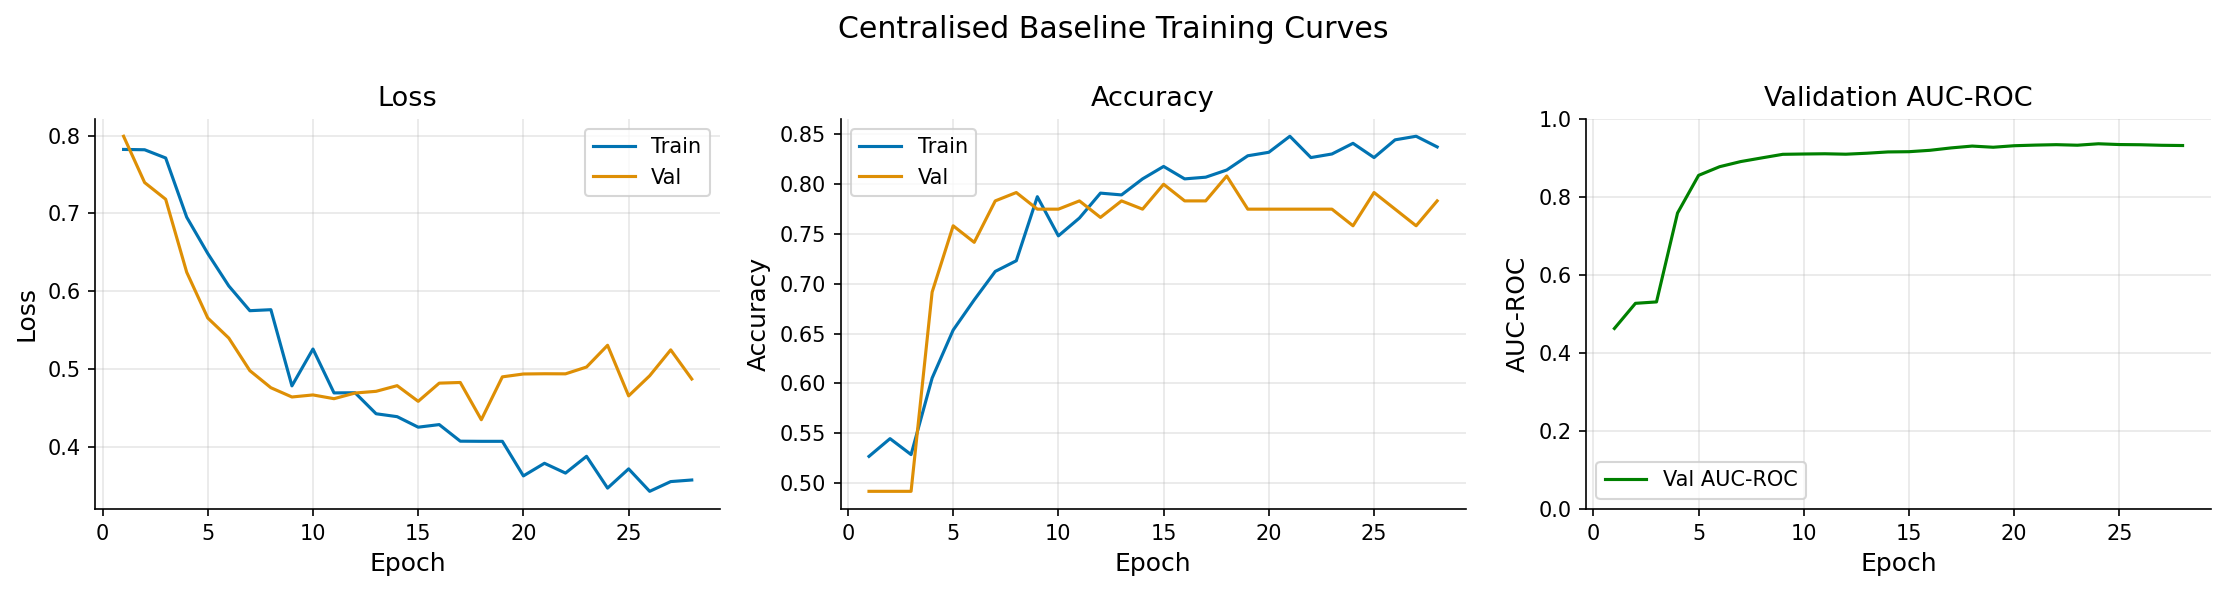

In [6]:
# Save training history
history_df = pd.DataFrame(history)
history_df.to_csv(paths["centralised_model_dir"] / "training_history.csv", index=False)
print("Training history saved.")
print(history_df.tail(5))

# Plot training curves
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

epochs_plot = history["epoch"]

axes[0].plot(epochs_plot, history["train_loss"], label="Train")
axes[0].plot(epochs_plot, history["val_loss"],   label="Val")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss"); axes[0].set_title("Loss")
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(epochs_plot, history["train_acc"], label="Train")
axes[1].plot(epochs_plot, history["val_acc"],   label="Val")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy"); axes[1].set_title("Accuracy")
axes[1].legend(); axes[1].grid(alpha=0.3)

axes[2].plot(epochs_plot, history["val_auc"], color="green", label="Val AUC-ROC")
axes[2].set_xlabel("Epoch"); axes[2].set_ylabel("AUC-ROC"); axes[2].set_title("Validation AUC-ROC")
axes[2].legend(); axes[2].grid(alpha=0.3)
axes[2].set_ylim(0, 1)

plt.suptitle("Centralised Baseline Training Curves")
plt.tight_layout()
save_figure(fig, "centralised_training_curves", paths["figures"], paths["paper_figures"])
plt.show()

## Quick Test-Set Evaluation

I load the best saved model and evaluate it on the test set. I do NOT tune any hyperparameters based on the test set — this is a one-shot evaluation.

In [8]:
from src.metrics import compute_metrics

# Load best model
best_model = build_model(pretrained=False, num_classes=2, dropout=cfg["model"]["dropout"])
best_model.load_state_dict(torch.load(best_model_path, map_location=DEVICE))
best_model = best_model.to(DEVICE)
best_model.eval()

# Collect test predictions
all_probs  = []
all_labels = []

with torch.no_grad():
    for images, labels, _ in test_loader:
        images = images.to(DEVICE)
        logits = best_model(images)
        probs  = torch.softmax(logits, dim=1)[:, 1]
        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(labels.numpy())

y_true = np.array(all_labels)
y_prob = np.array(all_probs)

# Save for later notebooks
np.save(paths["centralised_model_dir"] / "test_y_true.npy", y_true)
np.save(paths["centralised_model_dir"] / "test_y_prob.npy", y_prob)

# Compute metrics
metrics = compute_metrics(y_true, y_prob)

print("Centralised Baseline — Test Set Results:")
print("=" * 45)
for key, val in metrics.items():
    if isinstance(val, float):
        print(f"  {key:25s}: {val:.4f}")
    else:
        print(f"  {key:25s}: {val}")

Centralised Baseline — Test Set Results:
  auc_roc                  : 0.8939
  auc_prc                  : 0.9113
  threshold                : 0.2101
  sensitivity              : 0.8136
  specificity              : 0.8525
  ppv                      : 0.8421
  npv                      : 0.8254
  f1                       : 0.8276
  accuracy                 : 0.8333
  balanced_accuracy        : 0.8330
  tp                       : 48
  tn                       : 52
  fp                       : 9
  fn                       : 11
  n_positive               : 59
  n_negative               : 61
